<a href="https://colab.research.google.com/github/shagun53/brain-tumor-cnn-classifier/blob/main/Brain_Tumor_Detection_Using_CNNipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
!pip install tensorflow

In [14]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator


In [15]:
import zipfile

with zipfile.ZipFile('/content/brain_tumor_dataset.zip', 'r') as z:
    z.extractall('/content/brain_tumor_dataset')

In [16]:
import os
for root, dirs, files_list in os.walk('/content/brain_tumor_dataset'):
    for d in dirs:
        path = os.path.join(root, d)
        count = len(os.listdir(path))
        print(f'{path}: {count} images')

/content/brain_tumor_dataset/no: 98 images
/content/brain_tumor_dataset/yes: 155 images
/content/brain_tumor_dataset/brain_tumor_dataset: 2 images
/content/brain_tumor_dataset/brain_tumor_dataset/no: 98 images
/content/brain_tumor_dataset/brain_tumor_dataset/yes: 155 images


In [17]:
!find /content/brain_tumor_dataset -maxdepth 2 -type d

/content/brain_tumor_dataset
/content/brain_tumor_dataset/no
/content/brain_tumor_dataset/yes
/content/brain_tumor_dataset/brain_tumor_dataset
/content/brain_tumor_dataset/brain_tumor_dataset/no
/content/brain_tumor_dataset/brain_tumor_dataset/yes


In [18]:
import shutil

shutil.rmtree('/content/brain_tumor_dataset/brain_tumor_dataset')

In [19]:
!find /content/brain_tumor_dataset -maxdepth 2 -type d

/content/brain_tumor_dataset
/content/brain_tumor_dataset/no
/content/brain_tumor_dataset/yes


In [24]:
training_set = train_datagen.flow_from_directory(
    '/content/brain_tumor_dataset',
    target_size=(128,128),
    batch_size=32,
    class_mode='binary',
    subset='training'
)

validation_set = train_datagen.flow_from_directory(
    '/content/brain_tumor_dataset',
    target_size=(128,128),
    batch_size=32,
    class_mode='binary',
    subset='validation'
)

Found 203 images belonging to 2 classes.
Found 50 images belonging to 2 classes.


In [25]:
!find /content/brain_tumor_dataset -type f | head

/content/brain_tumor_dataset/no/no 99.jpg
/content/brain_tumor_dataset/no/29 no.jpg
/content/brain_tumor_dataset/no/20 no.jpg
/content/brain_tumor_dataset/no/N17.jpg
/content/brain_tumor_dataset/no/39 no.jpg
/content/brain_tumor_dataset/no/No15.jpg
/content/brain_tumor_dataset/no/15 no.jpg
/content/brain_tumor_dataset/no/8 no.jpg
/content/brain_tumor_dataset/no/no 923.jpg
/content/brain_tumor_dataset/no/no 4.jpg


In [26]:
print(training_set.class_indices)
print("Training images:", training_set.samples)
print("Validation images:", validation_set.samples)

{'no': 0, 'yes': 1}
Training images: 203
Validation images: 50


In [27]:
import os

yes_count = len(os.listdir('/content/brain_tumor_dataset/yes'))
no_count = len(os.listdir('/content/brain_tumor_dataset/no'))

print("Yes:", yes_count)
print("No:", no_count)

Yes: 155
No: 98


In [28]:
import tensorflow as tf

cnn = tf.keras.models.Sequential()

cnn.add(tf.keras.Input(shape=(128,128,3)))

cnn.add(tf.keras.layers.Conv2D(
    filters=32,
    kernel_size=3,
    activation='relu',
    input_shape=[128,128,3])
)
cnn.add(tf.keras.layers.MaxPool2D(pool_size=2, strides=2))

cnn.add(tf.keras.layers.Conv2D(
    filters=32,
    kernel_size=3,
    activation='relu',
    input_shape=[128,128,3])
)
cnn.add(tf.keras.layers.MaxPool2D(pool_size=2, strides=2))

cnn.add(tf.keras.layers.Flatten())

cnn.add(tf.keras.layers.Dense(units=128, activation='relu'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [29]:
cnn.add(tf.keras.layers.Dense(units=1, activation='sigmoid'))

In [30]:
!find /content/brain_tumor_dataset -type f | head

/content/brain_tumor_dataset/no/no 99.jpg
/content/brain_tumor_dataset/no/29 no.jpg
/content/brain_tumor_dataset/no/20 no.jpg
/content/brain_tumor_dataset/no/N17.jpg
/content/brain_tumor_dataset/no/39 no.jpg
/content/brain_tumor_dataset/no/No15.jpg
/content/brain_tumor_dataset/no/15 no.jpg
/content/brain_tumor_dataset/no/8 no.jpg
/content/brain_tumor_dataset/no/no 923.jpg
/content/brain_tumor_dataset/no/no 4.jpg


In [31]:
cnn.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [32]:
history=cnn.fit(x=training_set, validation_data=validation_set, epochs=100)

Epoch 1/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 8s 993ms/step - accuracy: 0.5665 - loss: 0.8475 - val_accuracy: 0.6200 - val_loss: 0.6848
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 669ms/step - accuracy: 0.6355 - loss: 0.6169 - val_accuracy: 0.7600 - val_loss: 0.5776
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 896ms/step - accuracy: 0.7635 - loss: 0.5907 - val_accuracy: 0.7800 - val_loss: 0.6034
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 683ms/step - accuracy: 0.7537 - loss: 0.5222 - val_accuracy: 0.6800 - val_loss: 0.5547
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 701ms/step - accuracy: 0.7635 - loss: 0.4805 - val_accuracy: 0.6200 - val_loss: 0.5950
Epoch 6/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 10s 746ms/step - accuracy: 0.7980 - loss: 0.4823 - val_accuracy: 0.7800 - val_loss: 0.4940
Epoch 7/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 915ms/step - accuracy: 0.8177 - loss: 0.4286 - val_accuracy: 0.7400 - val_loss: 0.4499
Epoch 8/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 682ms/step - accuracy: 0.8128 - loss: 0.4244 - val_accuracy: 0.7600 - 

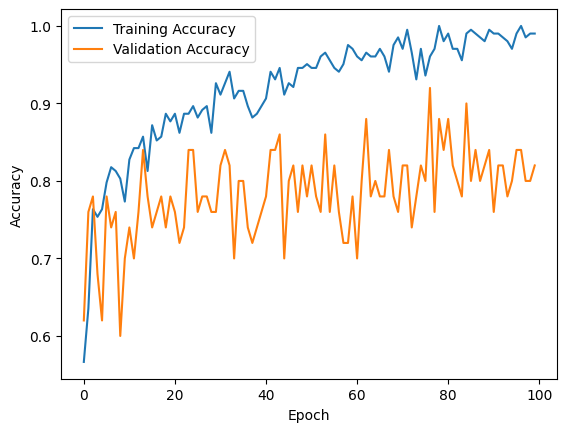

In [33]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.legend(['Training Accuracy', 'Validation Accuracy'])
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.show()

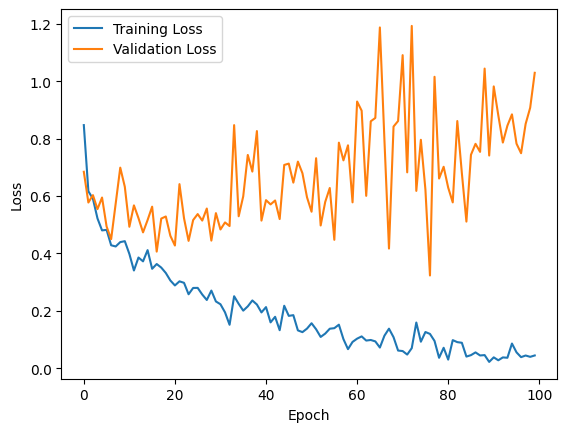

In [34]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.legend(['Training Loss', 'Validation Loss'])
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

In [36]:
from tensorflow.keras.callbacks import ModelCheckpoint

checkpoint = ModelCheckpoint(
    'best_model.keras',
    monitor='val_accuracy',
    save_best_only=True
)

In [37]:
loss, acc = cnn.evaluate(validation_set)

print("Validation Accuracy:", acc*100)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 96ms/step - accuracy: 0.8400 - loss: 0.7737
Validation Accuracy: 83.99999737739563


In [39]:
oss, acc = cnn.evaluate(training_set)

print("Training Accuracy:", acc*100)

7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 455ms/step - accuracy: 0.9803 - loss: 0.0452
Training Accuracy: 98.02955389022827
